In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW = Path(r"E:\ipl-analytics\data\raw")
PROCESSED = Path(r"E:\ipl-analytics\data\processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

In [2]:
matches = pd.read_csv(RAW / "matches.csv")
deliveries = pd.read_csv(RAW / "deliveries.csv", low_memory=False)

print("=== matches.csv ===")
print(f"Shape : {matches.shape}")
print(f"Columns : {list(matches.columns)}\n")

print("=== deliveries ===")
print(f"Shape : {deliveries.shape}")
print(f"Columns : {list(deliveries.columns)}\n")

print("=== matches datatypes ===")
print(matches.dtypes, "\n")

print("=== deliveries datatypes ===")
print(deliveries.dtypes, "\n")



=== matches.csv ===
Shape : (1243, 20)
Columns : ['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

=== deliveries ===
Shape : (295732, 17)
Columns : ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

=== matches datatypes ===
match_id             int64
season                 str
city                   str
date                   str
match_type             str
player_of_match        str
venue                  str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result                 str
result_margin      float64
target_runs        floa

In [3]:
print("=== nulls in matches ===")
null_matches = matches.isnull().sum()
print(null_matches[null_matches > 0], "\n")

print("=== nulls in deliveries ===")
null_deliveries = deliveries.isnull().sum()
print(null_deliveries[null_deliveries > 0], "\n")

=== nulls in matches ===
city                 51
match_type          148
player_of_match       9
winner                5
result_margin        19
target_runs         151
target_overs        151
super_over          148
method             1222
umpire1             148
umpire2             148
dtype: int64 

=== nulls in deliveries ===
extras_type         281607
player_dismissed    281027
dismissal_kind      281027
fielder             285011
dtype: int64 



In [4]:
print("=== matches.describe() ===")
print(matches.describe(include="all").T, "\n")

print("=== deliveries.describe() ===")
print(deliveries.describe().T, "\n")

=== matches.describe() ===
                  count unique                  top  freq          mean  \
match_id         1243.0    NaN                  NaN   NaN  966928.56959   
season             1243     19                 2013    76           NaN   
city               1192     37               Mumbai   187           NaN   
date               1243    947           2008-04-19     2           NaN   
match_type         1095      8               League  1029           NaN   
player_of_match    1234    321       AB de Villiers    25           NaN   
venue              1243     60         Eden Gardens    77           NaN   
team1              1243     19  Chennai Super Kings   142           NaN   
team2              1243     19       Mumbai Indians   152           NaN   
toss_winner        1243     19       Mumbai Indians   160           NaN   
toss_decision      1243      2                field   825           NaN   
winner             1238     20       Mumbai Indians   157           NaN  

In [5]:
print("=== unique teams in matches ===")
all_teams = pd.concat([matches["team1"], matches["team2"]]).unique()
print(sorted(all_teams), "\n")

print("=== seasons in a dataset ===")
print(sorted(matches["season"].unique()), "\n")

print("=== Venues (top 15 by match count ===")
print(matches["venue"].value_counts().head(15), "\n")

print("=== Toss Descision ===")
print(matches["toss_decision"].value_counts(), "\n")

=== unique teams in matches ===
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad'] 

=== seasons in a dataset ===
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026'] 

=== Venues (top 15 by match count ===
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Wankhede Stadium, Mumbai                      59
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Sta

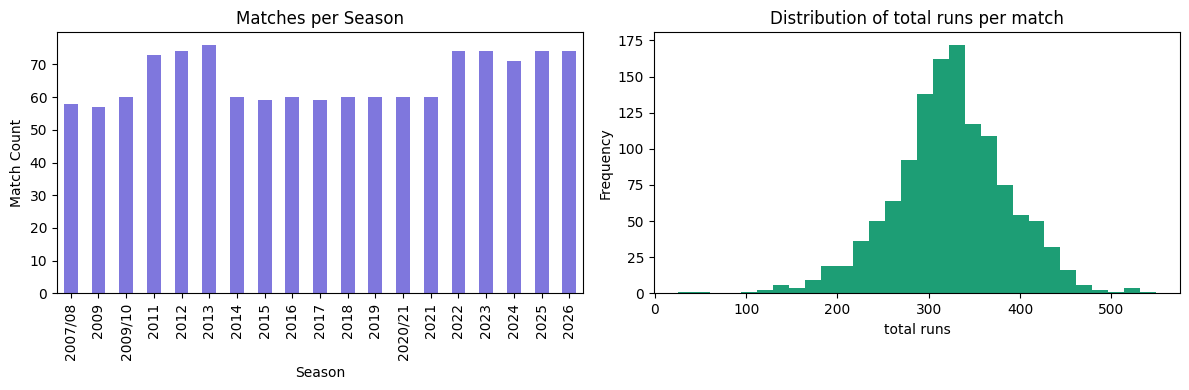

Sanity check chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

matches["season"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#7F77DD"
)
axes[0].set_title("Matches per Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Match Count")

deliveries.groupby("match_id")["total_runs"].sum().plot(
    kind="hist", bins=30, ax=axes[1], color="#1D9E75"
)
axes[1].set_title("Distribution of total runs per match")
axes[1].set_xlabel("total runs")

plt.tight_layout()
plt.savefig(r"E:\ipl-analytics\data\processed\sanity_check.png", dpi=120)
plt.show()
print("Sanity check chart saved")

In [7]:
merged = deliveries.merge(
    matches[["match_id", "season", "team1", "team2", "winner"]],
    left_on="match_id",
    right_on="match_id",
    how="left"
)

print("=== Merged Shappe")
print(merged.shape)

print("\n=== Merge null check (winner column) ===")
print(merged["winner"].isnull().sum(), "unmatched rows")

print("\n=== Sample merged rows ===")
print(merged.head(3).to_string())

=== Merged Shappe
(295732, 21)

=== Merge null check (winner column) ===
490 unmatched rows

=== Sample merged rows ===
   match_id  inning           batting_team                 bowling_team  over  ball       batter   bowler  non_striker  batsman_runs  extra_runs  total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder   season                        team1                  team2                 winner
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0     1   SC Ganguly  P Kumar  BB McCullum             0           1           1     legbyes          0              NaN            NaN     NaN  2007/08  Royal Challengers Bangalore  Kolkata Knight Riders  Kolkata Knight Riders
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0     2  BB McCullum  P Kumar   SC Ganguly             0           0           0         NaN          0              NaN            NaN     NaN  2007/08  Royal Challengers Bangalore  Kolkata Knigh

In [9]:
anomalies = {
    "duplicate_match_ids": int(matches["match_id"].duplicated().sum()),
    "matches_without_winner": int(matches["winner"].isnull().sum()),
    "deliveries_without_batsman": int(deliveries["batter"].isnull().sum()),
    "total_seasons": int(matches["season"].nunique()),
    "total_teams_ever": len(all_teams),
    "total_matches": len(matches),
    "total_deliveries": len(deliveries),
}

print("\n=== Anomaly Report ===")
for k, v in anomalies.items():
    print(f" {k:<35}: {v}")


=== Anomaly Report ===
 duplicate_match_ids                : 0
 matches_without_winner             : 5
 deliveries_without_batsman         : 0
 total_seasons                      : 19
 total_teams_ever                   : 19
 total_matches                      : 1243
 total_deliveries                   : 295732
